# Your First Spiral

This notebook will guide you through the most basic use case of plotting your first colliding wind nebula using default parameters. 

In [61]:
import sys; sys.path.append('../..')    # ignore this! just needed since this file is away from the xenomorph root dir

# start off by importing the relevant modules
import xenomorph.geometry as gm 
import xenomorph.systems as wrb

# now lets take a look at the systems that come pre-packaged
wrb.print_systems()

['apep', 'WR48a', 'WR104', 'WR112', 'WR125', 'WR137', 'WR140']


We can see that there are a range of systems that come pre-installed. Let's take a look at WR140.

In [62]:
print(wrb.WR140)    # each system is stored as a dictionary with all of the orbital and geometric parameters
wrb.WR140_refs()  # where applicable, we've also stored the references for these parameters

{'m1': 8.4, 'm2': 20.0, 'eccentricity': 0.8964, 'inclination': 119.6, 'asc_node': 275.0, 'arg_peri': 133.2, 'open_angle': 80.0, 'period': 7.929774127310061, 'distance': 1670.0, 'windspeed1': 2600.0, 'windspeed2': 2400.0, 'turn_on': -135.0, 'turn_off': 135.0, 'gradual_turn': 0.5, 'oblate': 0.0, 'nuc_dist': 50.0, 'opt_thin_dist': 220.0, 'term_windspeed': 2600.0, 'accel_rate': -5.0, 'orb_sd': 80.0, 'orb_amp': 0.0, 'orb_min': 180, 'az_sd': 60.0, 'az_amp': 0.0, 'az_min': 90.0, 'comp_incl': 0.0, 'comp_az': 0, 'comp_open': 0.0, 'comp_reduction': 0.0, 'comp_plume': 0.0, 'comp_plume_sd': 0.0, 'comp_plume_max': 0.0, 'phase': 0.6, 'sigma': 2.0, 'histmax': 1.0, 'lum_power': 1.0, 'spin_inc': 0.0, 'spin_Omega': 0.0, 'windspeed_polar': 240.0, 'aniso_vel_mult': -6.2, 'aniso_vel_power': 3.53, 'open_angle_polar': 180.0, 'aniso_OA_mult': -6.05, 'aniso_OA_power': 3.53, 'star1amp': 0.0, 'star1sd': -1.0, 'star2amp': 0.0, 'star2sd': -1.0, 'star3amp': 0.0, 'star3sd': -1.0, 'star3dist': 0.0}
Han et al. 2022 - 

There's a lot of parameters here, but many of them apply to only some systems. The main ones to consider are your orbital parameters and shock geometry parameters.

For now, let's generate a single WR140 shell and plot it:

In [63]:
star_data = wrb.WR140.copy()    # always a good idea to copy our data to a new dict

# the dust_plume() func generates the point cloud
particles, weights = gm.dust_plume(star_data) 
# convert this into something plottable with the smooth_histogram2d func
X, Y, H = gm.smooth_histogram2d(particles, weights, star_data)   # assumes 256x256 pixels as default
# X and Y are our bin locations, and H is our pixel information

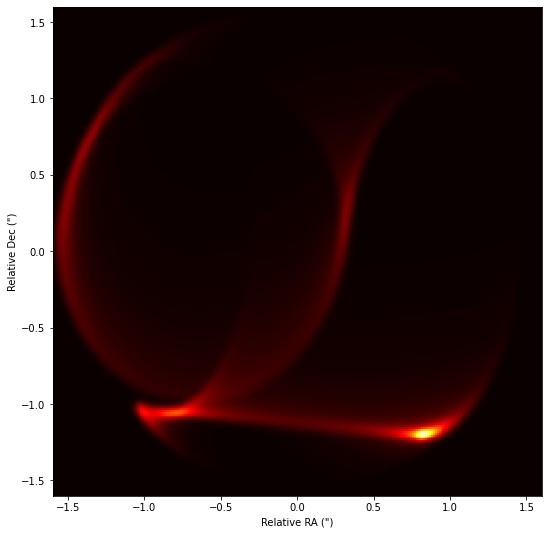

In [64]:
# now let's plot it
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 9))
ax.pcolormesh(X, Y, H, cmap='hot', rasterized=True)
ax.set(aspect='equal', ylabel='Relative Dec (")', xlabel='Relative RA (")')

plt.show()

Excellent! We can clearly our beautiful spiral geometry working right out of the box. If we compare this to the real images of WR140's innermost shell, though, we can immediately see that this nebula is missing the binary stars at it's centre! Thankfully we have functionality to add them in (purely for visual purposes):

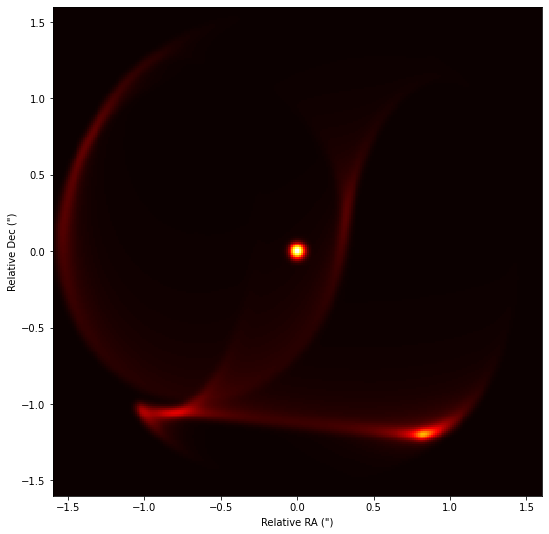

In [65]:
# we manually 'tack on' two gaussians into the appropriate location of the stars in the image
star_data['star1amp'] = 0.8; star_data['star2amp'] = 0.8    # how bright each star is (usually 0->1, but can be higher)
star_data['star1sd'] = -1.5; star_data['star2sd'] = -1.5    # how wide the gaussians are (log scale of pixels)
H_stars = gm.add_stars(X[0, :], Y[:, 0], H, star_data)

# now we replot:
fig, ax = plt.subplots(figsize=(9, 9))
ax.pcolormesh(X, Y, H_stars, cmap='hot', rasterized=True)
ax.set(aspect='equal', ylabel='Relative Dec (")', xlabel='Relative RA (")')

plt.show()

We can see that the inclusion of the stars in the centre washes out the luminosity of the surrounding nebula. We can change the scaling of the brightness with the `'histmax'` and `'lum_power'` parameters. The former has a default value of 1.0 and must be greater than 0.0; if we reduce this number, we bring up the dim parts of the nebula. The latter changes the flux scaling of all the pixels. `'lum_power' = 0.5` would be a $F^{1/2}$ scaling of flux, for example.

Let's regenerate and replot one last time to change the scaling of the nebula luminosity.

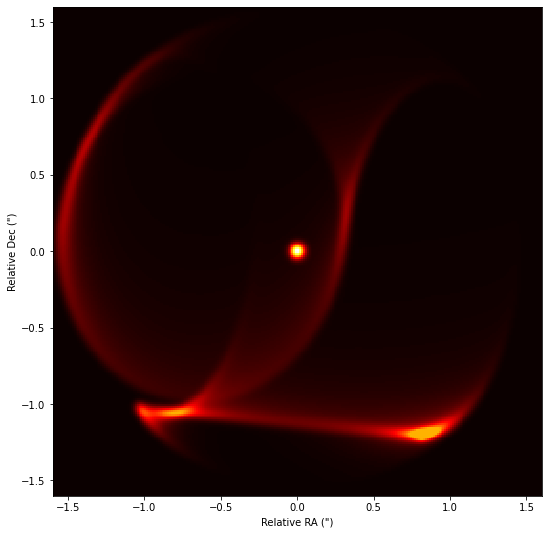

In [66]:
# star_data['lum_power'] = 0.7
star_data['histmax'] = 0.5
particles, weights = gm.dust_plume(star_data) 
X, Y, H = gm.smooth_histogram2d(particles, weights, star_data)
H_stars = gm.add_stars(X[0, :], Y[:, 0], H, star_data)

fig, ax = plt.subplots(figsize=(9, 9))
ax.pcolormesh(X, Y, H_stars, cmap='hot', rasterized=True)
ax.set(aspect='equal', ylabel='Relative Dec (")', xlabel='Relative RA (")')

plt.show()

A beautiful innermost shell! Now, chances are that you've seen the JWST image of WR140:

<img src="assets/wr140-jwst.jpg" alt="WR140 JWST" width="400"/>

How do we produce multiple shells at a time like that?

This is a difficult thing to do at run time, since the xenomorph code is made in JAX which requires fixed length arrays for the just-in-time compilation. Fortunately, I've come up with a somewhat cursed solution for now: I have a list of pre-compiled functions for a given number of shells (up to and including 20). We can access the list like so

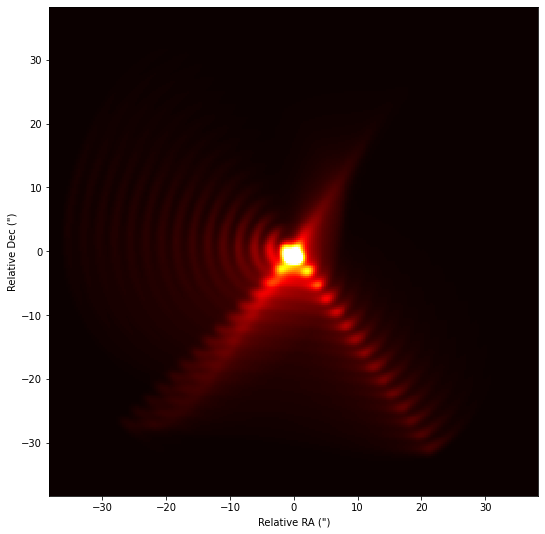

In [68]:
shells = 15     # define the number of shells we want to generate
jwst_particles, jwst_weights = gm.gui_funcs[shells-1](star_data)    # gm.gui_funcs[shells - 1]() will generate the appropriate number of shells

# now do everything just the same as before
jwst_X, jwst_Y, jwst_H = gm.smooth_histogram2d(jwst_particles, jwst_weights, star_data)
jwst_H_stars = gm.add_stars(jwst_X[0, :], jwst_Y[:, 0], jwst_H, star_data)

fig, ax = plt.subplots(figsize=(9, 9))
ax.pcolormesh(jwst_X, jwst_Y, jwst_H_stars, cmap='hot', rasterized=True)
ax.set(aspect='equal', ylabel='Relative Dec (")', xlabel='Relative RA (")')

plt.show()

And that's it! Go forth and make some cool spirals for any of our pre-packaged systems, or make your own custom system!